#### Eeg eye state
All data is from one continuous EEG measurement with the Emotiv EEG Neuroheadset. The duration of the measurement was 117 seconds.<br>The target values is eye detection: 1 means eye closed and 0 means eye open.<br>
Source: https://www.openml.org/search?type=data&sort=runs&status=active&id=1471

In [3]:
# LIST OF TASKS: 
# Explore and cleaning the data
# Use at least 2 feature selection tools
# Check redundancy and multicollinearity
# Remove features only if justified
# Create at least one type of new feature
# Try DFS or interaction features or cluster profiling
# Try PCA if useful
# Handle high cardinality features if needed
# Re-analyze after feature engineering
# Compare original vs modified dataset
# Judge realism and usefulness

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
import mne


import phik
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

<h3><center>Understanding and Exploring the Dataset<h3>

In [5]:
# The file is in ARFF format, so I use scipy to load it
data, meta = arff.loadarff(r"Datasets\EEG_Eye+State.csv")
df = pd.DataFrame(data)
df['eyeDetection'] = df['eyeDetection'].astype(int)
df.head()

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
0,4329.23,4009.23,4289.23,4148.21,4350.26,4586.15,4096.92,4641.03,4222.05,4238.46,4211.28,4280.51,4635.90,4393.85,0
1,4324.62,4004.62,4293.85,4148.72,4342.05,4586.67,4097.44,4638.97,4210.77,4226.67,4207.69,4279.49,4632.82,4384.10,0
2,4327.69,4006.67,4295.38,4156.41,4336.92,4583.59,4096.92,4630.26,4207.69,4222.05,4206.67,4282.05,4628.72,4389.23,0
3,4328.72,4011.79,4296.41,4155.90,4343.59,4582.56,4097.44,4630.77,4217.44,4235.38,4210.77,4287.69,4632.31,4396.41,0
4,4326.15,4011.79,4292.31,4151.28,4347.69,4586.67,4095.90,4627.69,4210.77,4244.10,4212.82,4288.21,4632.82,4398.46,0


In [6]:
# i am gonna  create time index from the sampling rate.
sampling_rate = len(df)/117
df.insert(0, 'time_second', np.arange(len(df))/sampling_rate)
# 117 seconds of recording, so the sampling rate is 14980/117 is almost 128 Hz

In [7]:
# Later I need to compare the original and optimized DSs.
df_original = df.copy()

In [8]:
df.info()
# 14980 rows, 15 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14980 entries, 0 to 14979
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   time_second   14980 non-null  float64
 1   AF3           14980 non-null  float64
 2   F7            14980 non-null  float64
 3   F3            14980 non-null  float64
 4   FC5           14980 non-null  float64
 5   T7            14980 non-null  float64
 6   P7            14980 non-null  float64
 7   O1            14980 non-null  float64
 8   O2            14980 non-null  float64
 9   P8            14980 non-null  float64
 10  T8            14980 non-null  float64
 11  FC6           14980 non-null  float64
 12  F4            14980 non-null  float64
 13  F8            14980 non-null  float64
 14  AF4           14980 non-null  float64
 15  eyeDetection  14980 non-null  int32  
dtypes: float64(15), int32(1)
memory usage: 1.8 MB


In [9]:
df.duplicated().sum()
# no duplicates. also no missing values

0

In [10]:
# Let's check the target value 
df['eyeDetection'].value_counts()

eyeDetection
0    8257
1    6723
Name: count, dtype: int64

In [11]:
df.describe().round(2)

,time_second,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
count,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00,14980.00
mean,58.50,4321.92,4009.77,4264.02,4164.95,4341.74,4644.02,4110.40,4616.06,4218.83,4231.32,4202.46,4279.23,4615.21,4416.44,0.45
std,33.78,2492.07,45.94,44.43,5216.40,34.74,2924.79,4600.93,29.29,2136.41,38.05,37.79,41.54,1208.37,5891.29,0.50
min,0.00,1030.77,2830.77,1040.00,2453.33,2089.74,2768.21,2086.15,4567.18,1357.95,1816.41,3273.33,2257.95,86.67,1366.15,0.00
25%,29.25,4280.51,3990.77,4250.26,4108.21,4331.79,4611.79,4057.95,4604.62,4190.77,4220.51,4190.26,4267.69,4590.77,4342.05,0.00
50%,58.50,4294.36,4005.64,4262.56,4120.51,4338.97,4617.95,4070.26,4613.33,4199.49,4229.23,4200.51,4276.92,4603.08,4354.87,0.00
75%,87.74,4311.79,4023.08,4270.77,4132.31,4347.18,4626.67,4083.59,4624.10,4209.23,4239.49,4211.28,4287.18,4617.44,4372.82,1.00
max,116.99,309231.00,7804.62,6880.51,642564.00,6474.36,362564.00,567179.00,7264.10,265641.00,6674.36,6823.08,7002.56,152308.00,715897.00,1.00


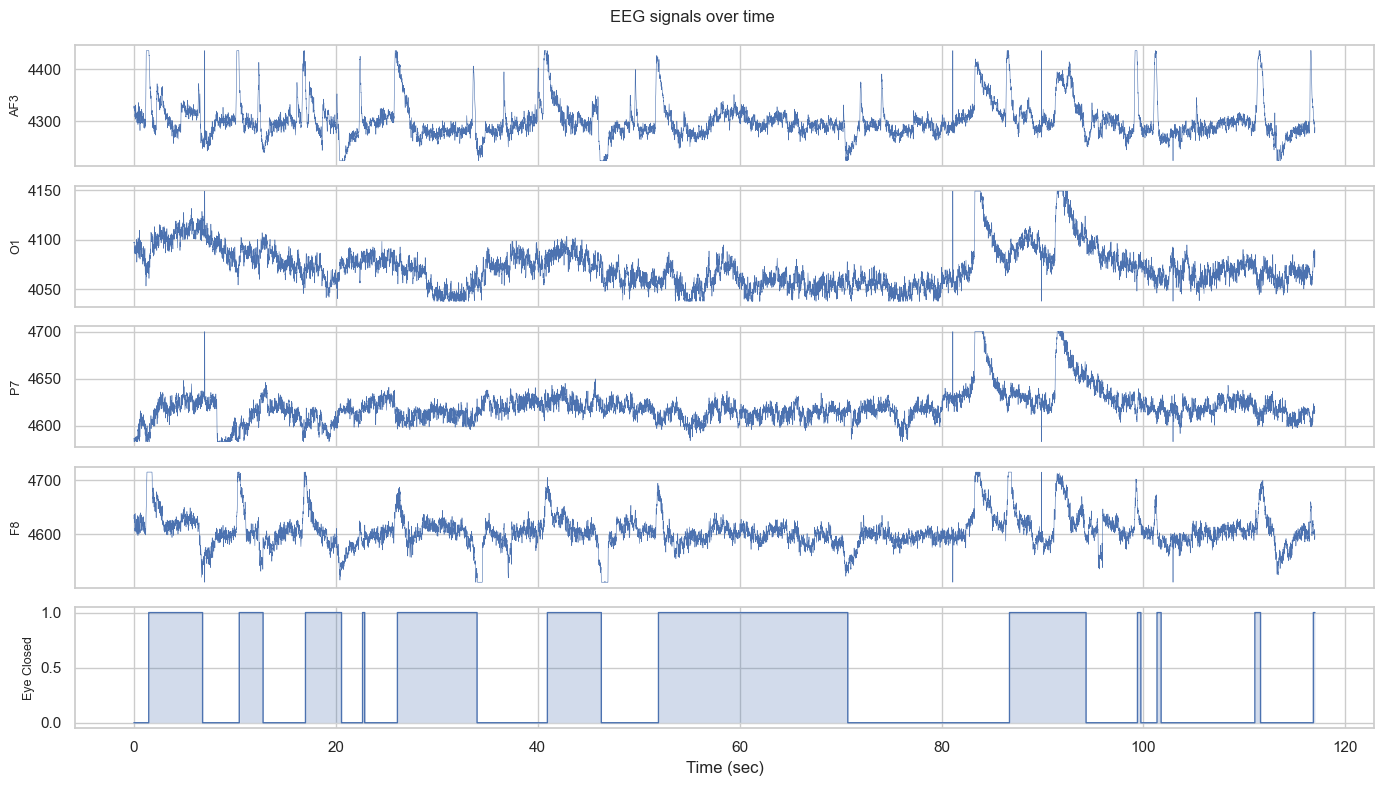

In [12]:
# I want to see the actual signals over time, picking channels from different brain parts

sns.set_theme(style='whitegrid', context='notebook')

sample_channels = ['AF3', 'O1', 'P7', 'F8']
fig, axes = plt.subplots(len(sample_channels) + 1, 1, figsize=(14, 8), sharex=True)

# I clip the signals to the 1 and 99 percentiles  
for ax, channel in zip(axes[:-1], sample_channels):
    low, high = df[channel].quantile([0.01, 0.99])
    signal_plot = df[channel].clip(low, high)

    sns.lineplot(x=df['time_second'], y=signal_plot, ax=ax,
                 estimator=None, errorbar=None, sort=False, linewidth=0.4)
    ax.set_ylabel(channel, fontsize=9)

sns.lineplot(data=df, x='time_second', y='eyeDetection', ax=axes[-1], estimator=None,
             errorbar=None, sort=False, drawstyle='steps-post', linewidth=1)

axes[-1].fill_between(df['time_second'], 0, df['eyeDetection'], alpha=0.25)
axes[-1].set_ylabel('Eye Closed', fontsize=9)
axes[-1].set_xlabel('Time (sec)')

plt.suptitle('EEG signals over time', fontsize=12)
plt.tight_layout()
plt.show()
# Source: https://seaborn.pydata.org/generated/seaborn.lineplot.html
# For debugging, I used QWEN. 
# What I can see from the plot: many channels change together at the same time. 

In [13]:
# Let me check the range of each EEG channel
# From describe(), most values are around 4000 to 4600.
signal_columns= [column for column in df.columns if column not in ['eyeDetection', 'time_second']]
print("Min values:")
print(df[signal_columns].min().round(2))
print("\nMaxx values:")
print(df[signal_columns].max().round(2))


Min values:
AF3    1030.77
F7     2830.77
F3     1040.00
FC5    2453.33
T7     2089.74
P7     2768.21
O1     2086.15
O2     4567.18
P8     1357.95
T8     1816.41
FC6    3273.33
F4     2257.95
F8       86.67
AF4    1366.15
dtype: float64

Maxx values:
AF3    309231.00
F7       7804.62
F3       6880.51
FC5    642564.00
T7       6474.36
P7     362564.00
O1     567179.00
O2       7264.10
P8     265641.00
T8       6674.36
FC6      6823.08
F4       7002.56
F8     152308.00
AF4    715897.00
dtype: float64


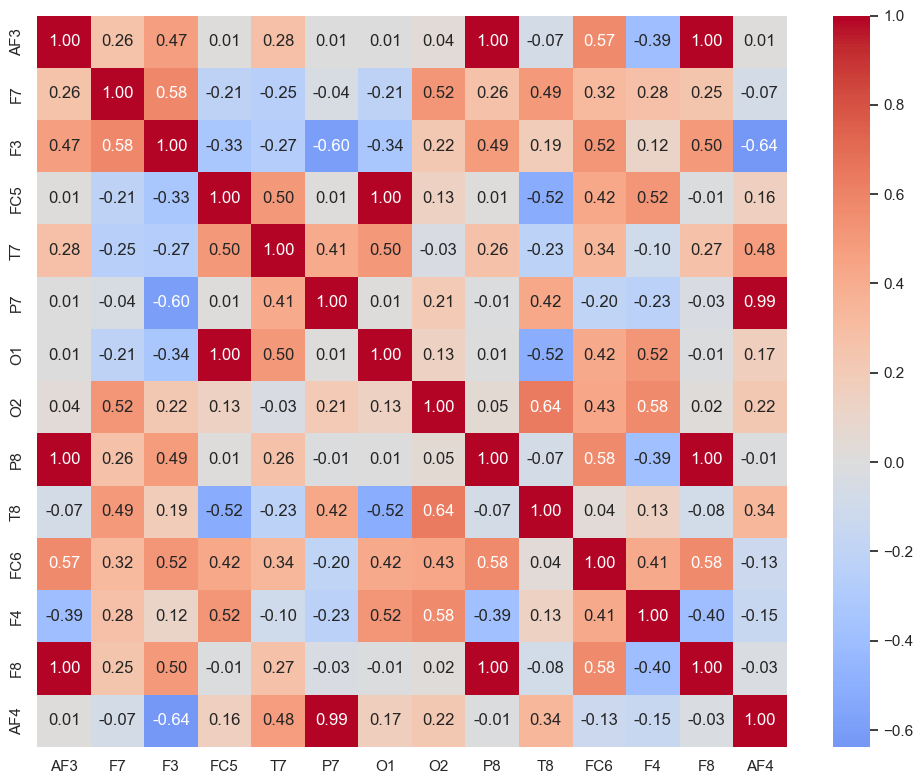

In [14]:
# let's check multicollinearity between channels
correlation = df[signal_columns].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.tight_layout()
plt.show()
# I can see many channel have high correlation. 
# for example AF3-f3, f4-f8, p7-O1 
# this means strong redundancy?,  that is why I want to use PCA later

<h3><center>Feature Engineering<h3>

### Anomaly 

In [15]:
# What I can see from above graphs: channels AF3, FC5, P7, O1, P8, F8, AF4 have extreme values
# I need to find how many rows have extreme values.
# Values above 8000 or below 1000 are outliers.
#  
anomalies_mask =(df[signal_columns]>8000).any(axis=1)|(df[signal_columns]<1000).any(axis=1)
print("Rows with anomaly values:",anomalies_mask.sum())

Rows with anomaly values: 4


In [16]:
# let's see what those rows look like.
df[anomalies_mask]

,time_second,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4,eyeDetection
898,7.013752,7222.05,3797.95,1040.00,3733.85,6040.51,362564.00,6350.26,5361.54,1357.95,6215.38,3273.33,3091.28,276.4100,715897.00,0
10386,81.118959,7398.46,2830.77,2457.44,642564.00,6474.36,8092.31,567179.00,5087.69,7143.59,1816.41,6137.95,6904.62,3504.1000,121026.00,0
11509,89.890053,309231.00,5500.51,6880.51,5416.41,5454.87,4002.05,2086.15,4770.26,265641.00,3914.87,6823.08,2257.95,152308.0000,5022.56,1
13179,102.933445,1030.77,7804.62,5762.56,2453.33,2089.74,2768.21,3581.54,7264.10,4586.15,6674.36,5170.77,7002.56,86.6667,1366.15,0


In [17]:
# I have 4 rows with anomalous values, so I am going to drop them, because it is only 4 rows.
df = df[~anomalies_mask].reset_index(drop=True)
print("Shape of the DS after dropping anomalies:", df.shape)

Shape of the DS after dropping anomalies: (14976, 16)


In [18]:
# I removed 4 rows that look clearly corrupted.
# I am not gonna do iqr clipping on this ds, because this is raw continuous 117 seconds ds 
# In this cell, I am gonna use mne to analyze the raw signals better. 

# Creating mne object
mne_object = mne.create_info(signal_columns, sfreq=sampling_rate, ch_types='eeg')
# Creating continuous object for annotating
raw_signals = mne.io.RawArray(df[signal_columns].to_numpy().T, mne_object)
raw_signals.set_montage('standard_1020', match_case=False)
raw_signals
# Source:https://mne.tools/stable/auto_tutorials/preprocessing/20_rejecting_bad_data.html
# https://numpy.org/devdocs/reference/generated/numpy.ptp.html

Creating RawArray with float64 data, n_channels=14, n_times=14976
    Range : 0 ... 14975 =      0.000 ...   116.961 secs
Ready.


<RawArray | 14 x 14976 (117.0 s), ~1.6 MiB, data loaded>

In [19]:
# In this cell, I am wanna see how big the signal swing is inside each window.

# Windows size 
epoch_len = 1.0
# Cutting signal into 1 second windows, I created continuous object already
epochs = mne.make_fixed_length_epochs(raw_signals, duration=epoch_len, preload=True)

# calculating max and min values each 1 second window.
# for each epoch and each channel, computing the range time, that is why I used axis=2 
amplitude= np.ptp(epochs.get_data(), axis=2)

amplitude_median = np.median(amplitude, axis=0)
amplitude_mad = np.median(np.abs(amplitude - amplitude_median), axis=0)
amplitude_threshold = amplitude_median + 6 * amplitude_mad


bad_epochs = np.where((amplitude >amplitude_threshold).any(axis=1))[0]

# Dropping bad epochs
epochs_clean = epochs.copy().drop(bad_epochs, reason='bad_amplitude')

print(f'Bad epochs: {len(bad_epochs)}')
print(f'Clean epochs: {len(epochs_clean)}')

Not setting metadata
116 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 116 events and 128 original time points ...
0 bad epochs dropped
Dropped 19 epochs: 1, 2, 8, 10, 12, 16, 20, 25, 33, 34, 46, 51, 83, 86, 91, 92, 99, 101, 111
Bad epochs: 19
Clean epochs: 97


Using matplotlib as 2D backend.


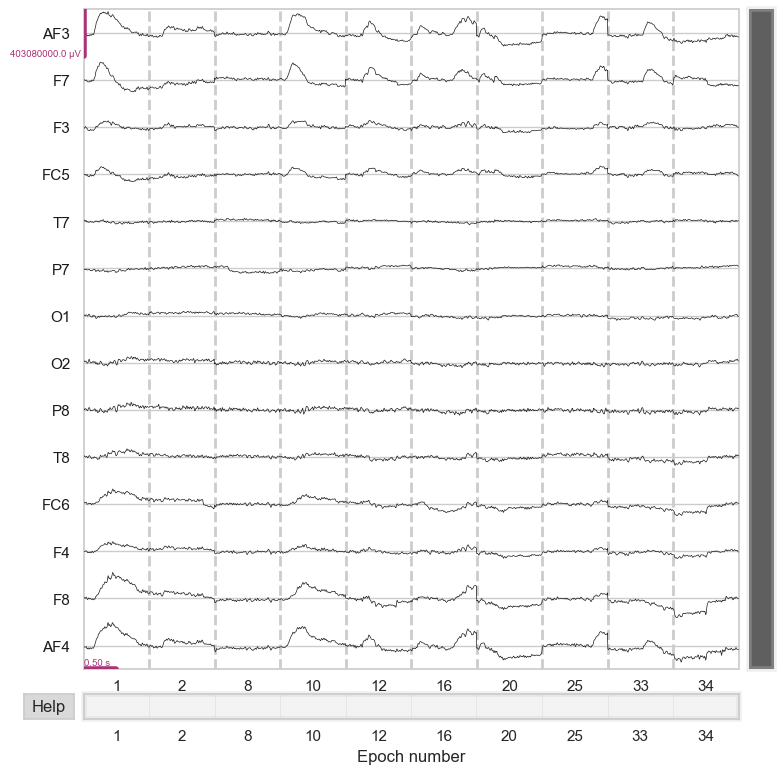

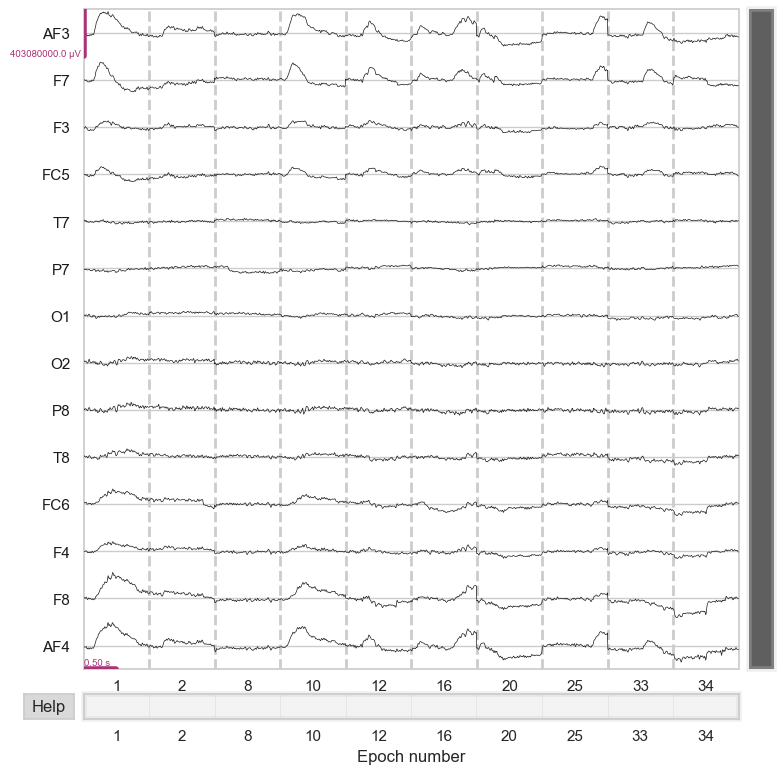

In [20]:
epochs[bad_epochs[:10]].plot(scalings='auto')

In [21]:
# number of rows inside one epoch
rows_per_epoch = len(epochs.times)

keep_epoch = np.zeros(len(epochs), dtype=bool)
keep_epoch[epochs_clean.selection] = True

keep_rows = np.repeat(keep_epoch, rows_per_epoch)
df= df.iloc[:len(keep_rows)][keep_rows].reset_index(drop=True)
print("Shape of the DS after dropping bad epochs:", df.shape)

Shape of the DS after dropping bad epochs: (12416, 16)


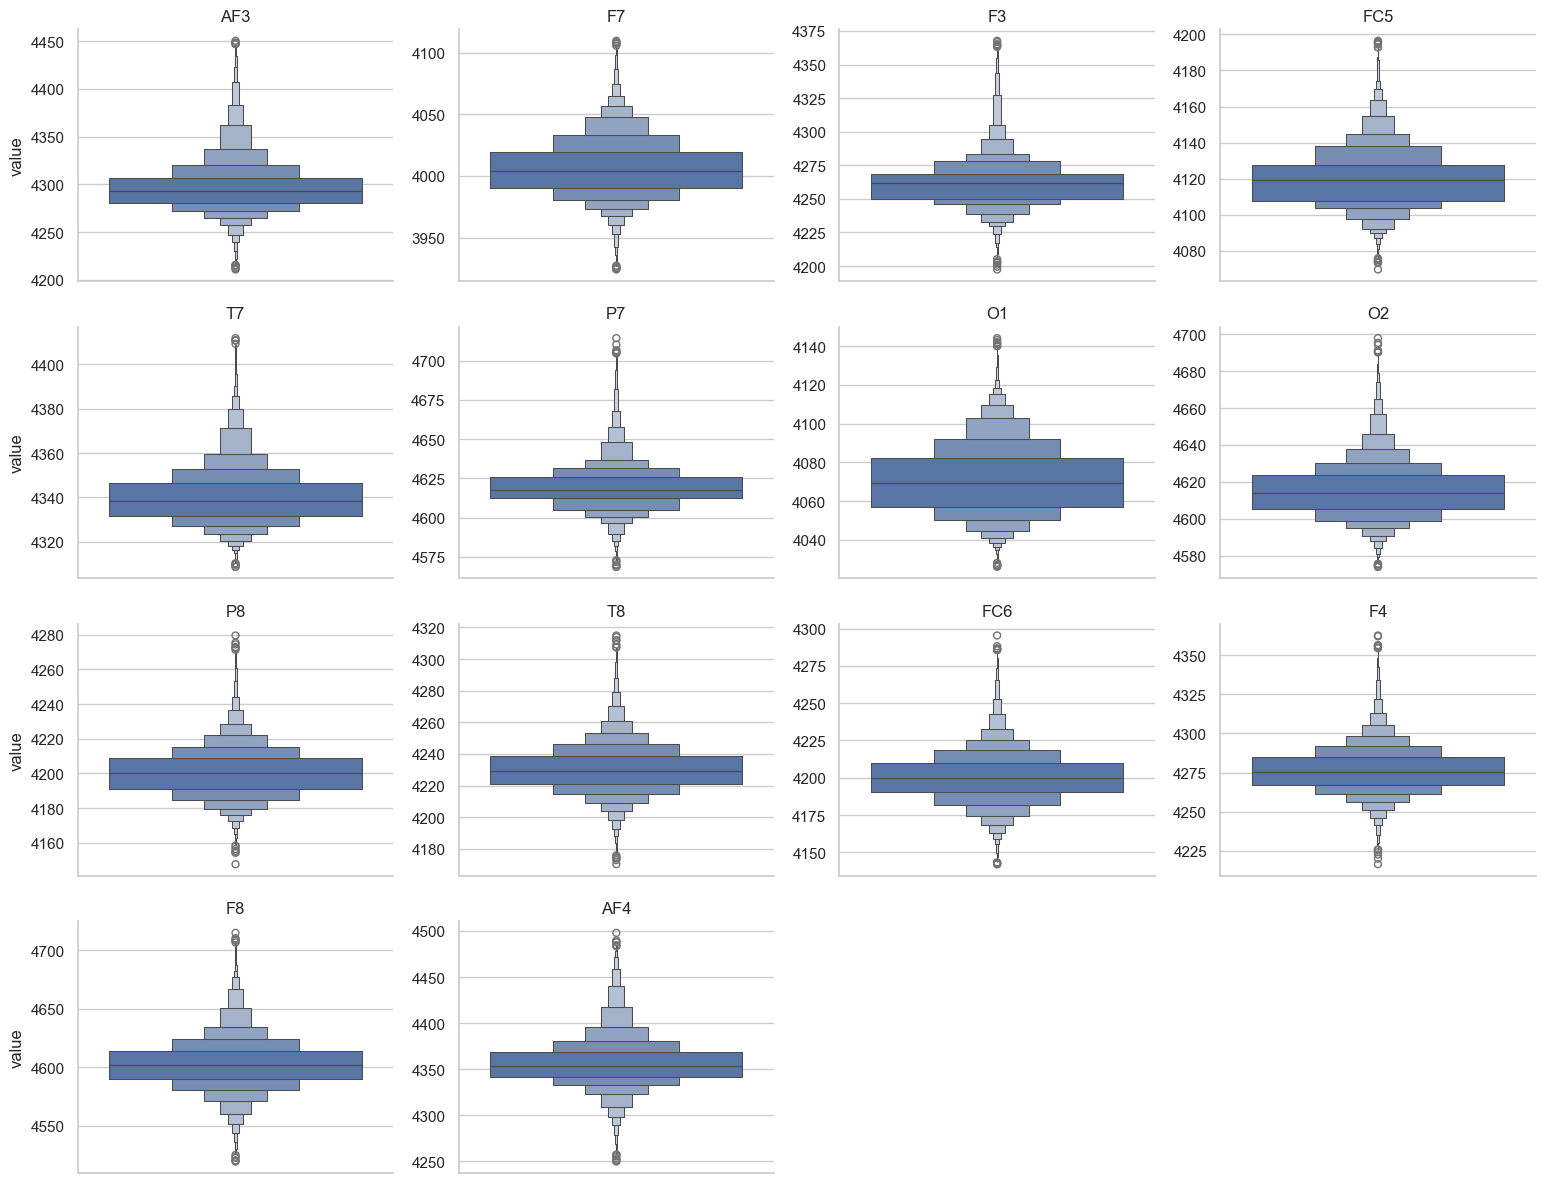

In [22]:
# Let me visualize the distribution of each channel.
columns = df[signal_columns].melt(var_name='channel', value_name='value')
group = sns.catplot(data=columns, y="value", col="channel", kind="boxen", col_wrap=4, sharey=False, height=3, aspect=1.3)
group.set_titles("{col_name}")
plt.show()

### Helper function

In [56]:
def evaluation(X_train, y_train, X_test, y_test, label=""):
    rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
    rf_model.fit(X_train, y_train)
    predicted = rf_model.predict(X_test)
    f1 = f1_score(y_test, predicted, average='macro')
    print(f"{label:30s} F1={f1:.3f}")
    return f1, predicted

In [24]:
df[signal_columns].describe().round(2)

,AF3,F7,F3,FC5,T7,P7,O1,O2,P8,T8,FC6,F4,F8,AF4
count,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00,12416.00
mean,4296.18,4006.09,4261.66,4119.59,4340.13,4619.16,4070.74,4615.02,4200.36,4230.38,4200.33,4276.37,4602.76,4356.28
std,26.91,24.06,16.69,16.25,12.81,13.67,18.38,14.91,14.26,15.30,17.19,14.74,22.30,27.00
min,4210.77,3924.10,4197.44,4069.74,4308.72,4568.72,4026.15,4573.85,4147.69,4170.26,4142.05,4216.41,4519.49,4249.74
25%,4280.51,3990.26,4250.26,4107.69,4331.79,4612.31,4056.92,4605.13,4191.28,4221.03,4190.26,4267.18,4590.26,4341.54
50%,4292.82,4004.10,4262.05,4119.49,4338.46,4617.95,4069.23,4613.85,4200.00,4229.23,4200.00,4275.38,4602.05,4353.85
75%,4306.67,4019.49,4268.21,4127.69,4346.67,4626.15,4082.05,4623.59,4208.72,4238.97,4209.74,4285.13,4614.36,4368.21
max,4450.26,4109.74,4367.69,4196.41,4411.79,4714.36,4144.10,4697.95,4279.49,4314.87,4295.38,4362.56,4714.87,4497.95


In [25]:
# how much does each channel correlate with the target?
target_corr = df[signal_columns].corrwith(df['eyeDetection']).sort_values()
print('Correlation with eyeDetection:')
print(target_corr.round(3))
# very low correlations, but that does not surprise me
# eeg signals relate to eye state through temporal patterns, not raw amplitude

Correlation with eyeDetection:
P7    -0.164
F7    -0.102
T7    -0.047
FC5   -0.047
O1    -0.011
O2     0.007
P8     0.015
F3     0.048
FC6    0.069
T8     0.104
F4     0.138
F8     0.160
AF3    0.160
AF4    0.199
dtype: float64


### Feature Selection

In [26]:
# Here I am going to use selectKBest with mutual info
# I chose mutual info because it captures nonlinear patterns.
X = df[signal_columns]
y = df['eyeDetection']

mutual_info_selector = SelectKBest(mutual_info_classif, k='all')
mutual_info_selector.fit(X, y)
mutual_info_scores = pd.Series(mutual_info_selector.scores_, index=signal_columns).sort_values(ascending=False)

print('Mutual Information scores:')
print(mutual_info_scores.round(3))

Mutual Information scores:
P7     0.044
O1     0.039
AF3    0.033
AF4    0.033
F8     0.024
F3     0.019
F4     0.018
T7     0.018
T8     0.016
P8     0.016
FC5    0.009
FC6    0.008
O2     0.005
F7     0.003
dtype: float64


In [27]:
# METHOD 2: Random Forest feature importance
# I use 80/20 split for train and test

split = int(0.8 * len(df))
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test =y.iloc[:split],y.iloc[split:]

random_forest = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
random_forest.fit(X_train, y_train)

random_forest_importance = pd.Series(random_forest.feature_importances_, index=signal_columns).sort_values(ascending=False)
print('Random Forest feature importance:')
print(random_forest_importance.round(3))

Random Forest feature importance:
P7     0.124
O1     0.108
F7     0.090
F8     0.081
AF4    0.072
F4     0.067
FC6    0.066
AF3    0.065
FC5    0.061
T7     0.060
F3     0.060
O2     0.053
T8     0.052
P8     0.042
dtype: float64


In [ ]:
# In this cell, I am gonna compare the two methods, do they agree on which channels are less important?
comparison = pd.DataFrame({'Mutual_info_score':mutual_info_scores,
                          'Mutual_info_rank':mutual_info_scores.rank(ascending=False).astype(int),
                          'Random_forest_score':random_forest_importance,
                          'Random_forest_rank':random_forest_importance.rank(ascending=False).astype(int)})

comparison['avg_rank'] = (comparison['Mutual_info_rank']+comparison['Random_forest_rank'])/2
comparison.round(3).sort_values('avg_rank')
# both methods agree that  t8 and 02 are the least important channels. 

,Mutual_info_score,Mutual_info_rank,Random_forest_score,Random_forest_rank,avg_rank
P7,0.044,1,0.124,1,1.0
O1,0.039,2,0.108,2,2.0
AF4,0.033,4,0.072,5,4.5
F8,0.024,5,0.081,4,4.5
AF3,0.033,3,0.065,8,5.5
F4,0.018,7,0.067,6,6.5
F3,0.019,6,0.060,11,8.5
F7,0.003,14,0.090,3,8.5
T7,0.018,8,0.060,10,9.0
FC6,0.008,12,0.066,7,9.5


In [29]:
# METHOD 3: PhiK correlation: 
phik_matrix = df[signal_columns + ['eyeDetection']].phik_matrix()

# I only care about the target column
phik_target = phik_matrix['eyeDetection'].drop('eyeDetection').sort_values(ascending=False)
print('PhiK correlation with eyeDetection:')
print(phik_target.round(3))
# I am not gonna drop channels yet. Here is my reasoning:
# All three methods (mutual info, Random Forest, PhiK), show different rankings
# I will create rolling features next, and those might change importance

interval columns not set, guessing: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection']
PhiK correlation with eyeDetection:
O1     0.334
P7     0.304
AF4    0.295
AF3    0.294
F8     0.244
F4     0.236
F7     0.192
F3     0.189
T8     0.184
FC6    0.182
P8     0.161
O2     0.136
T7     0.126
FC5    0.105
Name: eyeDetection, dtype: float64


In [30]:
# let me get score with all raw channels so I can compare later 
baseline_f1, _ = evaluation(X_train, y_train, X_test, y_test, "After dropping bad epochs cleaning")

After dropping bad epochs cleaning macro-F1=0.362


### Rolling temporal features

In [31]:
# I need to look at short windows to capture the pattern. 
# 64 samples is about 0.5 seconds.

window = 64
# what is the average signal level over the last 0.5 sec and how much it varies?
rolling_mean = df[signal_columns].rolling(window, min_periods=1).mean()
rolling_std = df[signal_columns].rolling(window, min_periods=1).std(ddof=0)

rolling_mean.columns = [f'{column}_mean' for column in signal_columns]
rolling_std.columns = [f'{column}_std' for column in signal_columns]

df_features = pd.concat([rolling_mean, rolling_std], axis=1)
df_features.head()

,AF3_mean,F7_mean,F3_mean,FC5_mean,T7_mean,P7_mean,O1_mean,O2_mean,P8_mean,T8_mean,...,T7_std,P7_std,O1_std,O2_std,P8_std,T8_std,FC6_std,F4_std,F8_std,AF4_std
0,4329.230,4009.2300,4289.2300,4148.210000,4350.260000,4586.1500,4096.920000,4641.030000,4222.050000,4238.460,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,4326.925,4006.9250,4291.5400,4148.465000,4346.155000,4586.4100,4097.180000,4640.000000,4216.410000,4232.565,...,4.105000,0.260000,0.260000,1.030000,5.640000,5.895000,1.795000,0.510000,1.540000,4.875000
2,4327.180,4006.8400,4292.8200,4151.113333,4343.076667,4585.4700,4097.093333,4636.753333,4213.503333,4229.060,...,5.494205,1.346205,0.245130,4.667864,6.172829,6.909226,1.977108,1.052278,2.941066,3.982236
3,4327.565,4008.0775,4293.7175,4152.310000,4343.205000,4584.7425,4097.180000,4635.257500,4214.487500,4230.640,...,4.763310,1.716674,0.260000,4.801486,5.611027,6.579685,1.964324,3.167882,2.548101,4.692853
4,4327.282,4008.8200,4293.4360,4152.104000,4344.102000,4585.1280,4096.924000,4633.744000,4213.744000,4233.332,...,4.622741,1.718143,0.562338,5.254155,5.234316,7.976293,2.301744,3.655746,2.284221,5.173869


In [37]:
# did rolling features actually help?, let me check correlation with target
target = df['eyeDetection']
raw_correlation = df[signal_columns].corrwith(target).abs().mean()
rolling_correlation = df_features.corrwith(target).abs().mean()

print(f'Raw channels: {raw_correlation:.3f}')
print(f'Rolling features: {rolling_correlation:.3f}')

Raw channels: 0.091
Rolling features: 0.088


In [ ]:
# For better evaluation, I am gonna use time series split
splitter = TimeSeriesSplit(n_splits=5)
tss_f1s = []
for train_idx, test_idx in splitter.split(df_features):
    f1, _ = evaluation(df_features.iloc[train_idx], y.iloc[train_idx],
                       df_features.iloc[test_idx], y.iloc[test_idx], "TSS fold")
    tss_f1s.append(f1)
print(f"F1 mean: {np.mean(tss_f1s):.3f} ± {np.std(tss_f1s):.3f}")


TSS fold                       macro-F1=0.577
TSS fold                       macro-F1=0.444
TSS fold                       macro-F1=0.722
TSS fold                       macro-F1=0.431
TSS fold                       macro-F1=0.417
F1 mean: 0.518 ± 0.117


In [55]:
X_roll_train = df_features.iloc[:split]
X_roll_test = df_features.iloc[split:]

roll_f1, roll_pred = evaluation(X_roll_train, y_train, X_roll_test, y_test, "Rolling features")

Rolling features               macro-F1=0.437


### Handling redundancy - PCA

In [47]:
# I fit scaler and pca on training data only to avoid data leakage
# if I fit on all data, test info leaks into the components

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_roll_train)
X_test_scaled = scaler.transform(X_roll_test)

# first let me check how many components I need
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
variance_95 = np.searchsorted(cumvar, 0.95) + 1
variance_99 =np.searchsorted(cumvar,0.99) +1

print(f'components for 95% :{variance_95}')
print(f'Components for 99% :{variance_99}')
# What I can see, the ds has redundancy. 
# pca keeps variance, not class information directly
#  so I still need to compare model performance before and after pca.

components for 95% :17
Components for 99% :24


In [48]:
# I am going to keep 95% of variance

pca = PCA(n_components=variance_95)
X_pca_train = pca.fit_transform(X_train_scaled)
X_pca_test = pca.transform(X_test_scaled)

print(f"Variance retained:{pca.explained_variance_ratio_.sum():.3f}")

original_correlation= pd.DataFrame(X_train_scaled).corr().abs()
pca_correlation = pd.DataFrame(X_pca_train).corr().abs()

mask_origignal = np.triu(np.ones(original_correlation.shape), k=1).astype(bool)
mask_pca = np.triu(np.ones(pca_correlation.shape), k=1).astype(bool)

print(f"Before PCA: {original_correlation.where(mask_origignal).max().max():.3f}")
print(f'After PCA: {pca_correlation.where(mask_pca).max().max():.3f}')
# I kept 17 pca and the retrained variance is 95.6 which is not bad. 

Variance retained:0.957
Before PCA: 0.936
After PCA: 0.000


### High-cardinality categoricals

In [34]:
# I skip this task, because all 14 features are continuous.

### Re-analyzing after feature engineering

In [49]:
# let me re run mutual info on rolling features to see if importance changed
roll_mutual= SelectKBest(mutual_info_classif, k='all')
roll_mutual.fit(df_features.iloc[:split], y.iloc[:split])
roll_mutual_scores = pd.Series(roll_mutual.scores_, index=df_features.columns).sort_values(ascending=False)

print('Top 10 rolling features by mutual info:')
print(roll_mutual_scores.head(10).round(3))
print(f'\nRaw channels mean mutual info: {mutual_info_scores.mean():.3f}')
print(f'Rolling features mean mutual info: {roll_mutual_scores.mean():.3f}')
# rolling features have higher than  mutual info with the target

Top 10 rolling features by mutual info:
P7_mean     0.111
FC6_mean    0.083
F8_mean     0.077
F4_mean     0.076
O2_mean     0.073
AF4_mean    0.065
O1_mean     0.061
P8_mean     0.058
F3_mean     0.056
T7_mean     0.055
dtype: float64

Raw channels mean mutual info: 0.020
Rolling features mean mutual info: 0.049


<h3><center>Comparing original vs optimized DSs<h3>

In [50]:
# In this cell, I am gonna compare row signals vs rolling features vs pca features 

raw_correlation = X_train.corr().abs()
roll_correlation = X_roll_train .corr().abs()
pca_correlation = pd.DataFrame(X_pca_train).corr().abs()

mask_raw = np.triu(np.ones(raw_correlation.shape), k=1).astype(bool)
mask_roll = np.triu(np.ones(roll_correlation.shape), k=1).astype(bool)
mask_pca = np.triu(np.ones(pca_correlation.shape), k=1).astype(bool)

y_tr = pd.Series(y_train).reset_index(drop=True)

raw_target = X_train.corrwith(y_tr).abs()
roll_target = X_roll_train.corrwith(y_tr).abs()
pca_target = pd.DataFrame(X_pca_train).corrwith(y_tr).abs()

print(f'Raw max correlation: {raw_correlation.where(mask_raw).max().max():.3f}')
print(f'Rolll max correlation: {roll_correlation.where(mask_roll).max().max():.3f}')
print(f'PCA max correlation: {pca_correlation.where(mask_pca).max().max():.3f}')
 
print(f'\nRaw target correlation: {raw_target.mean():.3f}')
print(f'Roll target correlation: {roll_target.mean():.3f}')
print(f'PCA target correlation: {pca_target.mean():.3f}')
# I found that rolling features did not reduce redundancy, but pca did.
# Also pca gave stronger average target correlation. 

Raw max correlation: 0.923
Rolll max correlation: 0.936
PCA max correlation: 0.000

Raw target correlation: 0.051
Roll target correlation: 0.068
PCA target correlation: 0.101


In [51]:
pca_f1, pca_pred = evaluation(X_pca_train, y_train, X_pca_test, y_test,
                              label=f'PCA ({variance_95} components)')
print(classification_report(y_test, pca_pred, target_names=['Open', 'Closed']))
# Metrics are terrible for closed.
# My action for removing the bad epochs and anomalies makes this dataset more imbalanced. 

PCA (17 components)            macro-F1=0.392
              precision    recall  f1-score   support

        Open       0.97      0.56      0.71      2391
      Closed       0.04      0.48      0.08        93

    accuracy                           0.56      2484
   macro avg       0.50      0.52      0.39      2484
weighted avg       0.93      0.56      0.68      2484



In [ ]:
# In this cell, I am gonna summarize the results of all parts in one table for better comparison.

final_summary = pd.DataFrame({
                              'Raw channels':{'Features':len(signal_columns), 'Rows':len(df_original),
                              'Mean correlation with target':df[signal_columns].corrwith(df['eyeDetection']).abs().mean(),'Macro-F1':baseline_f1}, 

                              'Rolling features':{'Features':df_features.shape[1],'Rows': len(df),
                              'Mean correlation with target':df_features.corrwith(df['eyeDetection']).abs().mean(),'Macro-F1':roll_f1},

                               'PCA':{'Features':variance_95,'Rows': len(df),
                               'Mean correlation with target':pd.DataFrame(X_pca_train).corrwith(y_train).abs().mean(),'Macro-F1':pca_f1}})

final_summary.round(3)
# pca  removed redundancy but did not improve F1 much
# the best pipeline is rolling features without PCA

,Raw channels,Rolling features,PCA
Features,14.000,28.000,17.000
Rows,14980.000,12416.000,12416.000
Mean correlation with target,0.091,0.088,0.101
Macro-F1,0.362,0.437,0.392


In [ ]:
# What I did :
# - exlored the and cleaned the ds
# - feature selection. 
# - created rolling features and tried pca. 


# What did not work:
# The ds is too small and imbalanced, the whole record is only 117 seconds, that is why the metrics are bad. 

# Since the ds is small, I dont think that the model will learn general patterns from this ds.